# Cardinal mock mask

Build a combined survey mask at nside=512 by intersecting:
- **nvisits > 1** in bands g, r, i, z  (DP2 survey maps, nside=256)
- **r-band 5σ depth > 23.5**  — two versions: point-source (`m5_ps`) and extended-source (`m5_ext`)
- **E(B-V) < 0.2**  (SFD98 dust map, nside=512)

nside=256 masks are upgraded to nside=512 with `healpy.ud_grade(pess=True)` before combining.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.io import fits

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [2]:
# ── File paths ────────────────────────────────────────────────────────────────
maps_dir = "/global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps_may"
sfd_file = "/pscratch/sd/a/anicola/DP2/data/SFD/EBV_SFD98_1_512.fits"

def nvisits_path(band):
    return f"{maps_dir}/dp2_public_catalog_n_visits_{band}_nside-256.fits"

depth_ps_r_path  = f"{maps_dir}/dp2_public_catalog_m5_ps_r_nside-256.fits"
depth_ext_r_path = f"{maps_dir}/dp2_public_catalog_m5_ext_r_nside-256.fits"

out_ps_path  = "/pscratch/sd/a/anicola/DP2/data/masks/cardinal_mask_m5ps_nside512.fits"
out_ext_path = "/pscratch/sd/a/anicola/DP2/data/masks/cardinal_mask_m5ext_nside512.fits"

NSIDE_OUT = 512
OMEGA_PIX  = hp.nside2pixarea(NSIDE_OUT, degrees=True)  # deg² per pixel

## 1. nvisits maps (g, r, i, z)

/tmp/ipykernel_104830/2277608885.py:2: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  nvisits = {b: hp.read_map(nvisits_path(b), verbose=False) for b in bands}
/tmp/ipykernel_104830/2277608885.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


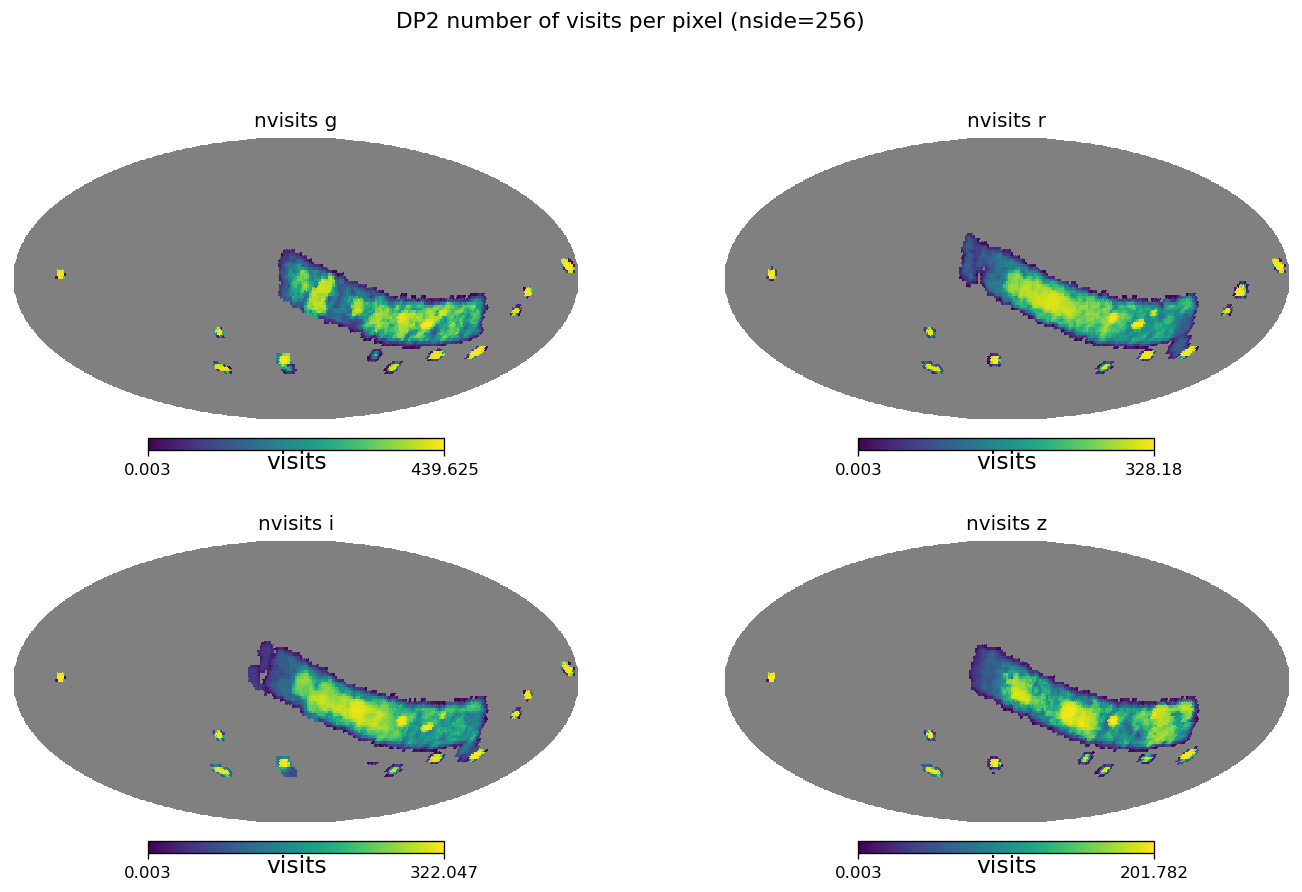

In [3]:
bands = ["g", "r", "i", "z"]
nvisits = {b: hp.read_map(nvisits_path(b), verbose=False) for b in bands}

fig = plt.figure(figsize=(14, 8))
for k, band in enumerate(bands):
    plt.subplot(2, 2, k + 1)
    hp.mollview(
        nvisits[band],
        title=f"nvisits {band}",
        unit="visits",
        norm="hist",
        hold=True,
        cmap="viridis",
    )
plt.suptitle("DP2 number of visits per pixel (nside=256)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 2. r-band depth: point-source vs extended-source

/tmp/ipykernel_104830/2337590409.py:1: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  depth_ps  = hp.read_map(depth_ps_r_path,  verbose=False)
/tmp/ipykernel_104830/2337590409.py:2: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  depth_ext = hp.read_map(depth_ext_r_path, verbose=False)
/tmp/ipykernel_104830/2337590409.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


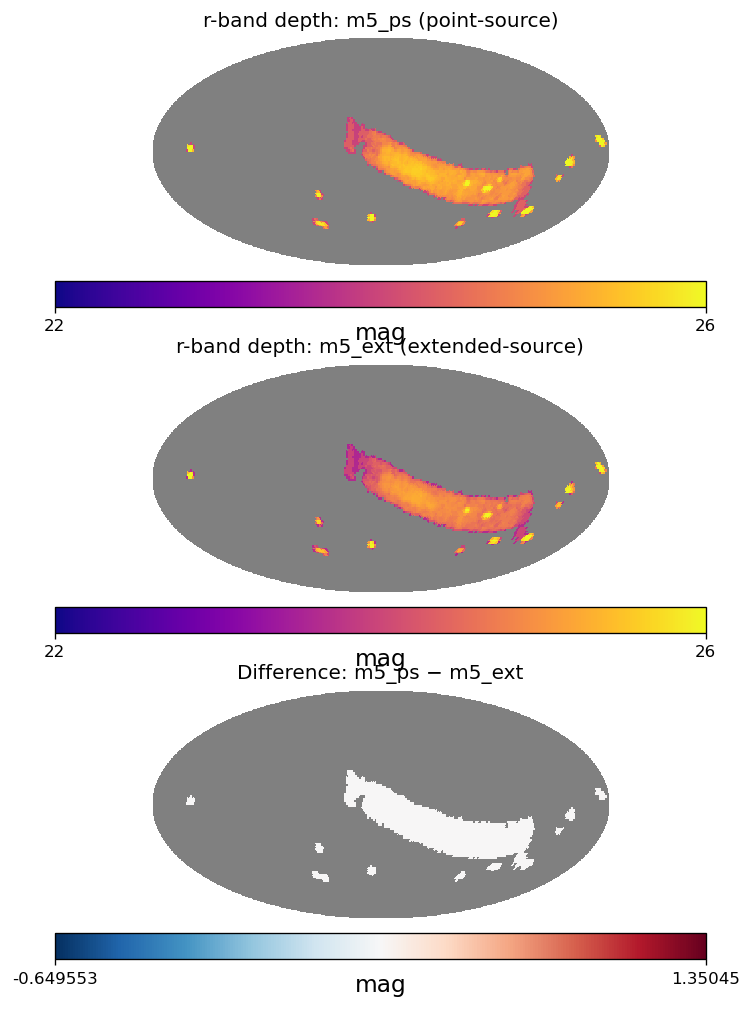

m5_ps  : median=25.037  p5=23.979  p95=25.740
m5_ext : median=24.686  p5=23.628  p95=25.389


In [4]:
depth_ps  = hp.read_map(depth_ps_r_path,  verbose=False)
depth_ext = hp.read_map(depth_ext_r_path, verbose=False)

# mask UNSEEN pixels for display
depth_ps_plot  = np.where(depth_ps  > 0, depth_ps,  hp.UNSEEN)
depth_ext_plot = np.where(depth_ext > 0, depth_ext, hp.UNSEEN)
diff_plot      = np.where((depth_ps > 0) & (depth_ext > 0), depth_ps - depth_ext, hp.UNSEEN)

fig = plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
hp.mollview(depth_ps_plot,  title="r-band depth: m5_ps (point-source)",
            unit="mag", min=22, max=26, hold=True, cmap="plasma")

plt.subplot(3, 1, 2)
hp.mollview(depth_ext_plot, title="r-band depth: m5_ext (extended-source)",
            unit="mag", min=22, max=26, hold=True, cmap="plasma")

plt.subplot(3, 1, 3)
hp.mollview(diff_plot, title="Difference: m5_ps − m5_ext",
            unit="mag", hold=True, cmap="RdBu_r")

plt.tight_layout()
plt.show()

# Footprint statistics
in_foot = depth_ps > 0
print(f"m5_ps  : median={np.median(depth_ps[in_foot]):.3f}  "
      f"p5={np.percentile(depth_ps[in_foot], 5):.3f}  "
      f"p95={np.percentile(depth_ps[in_foot], 95):.3f}")
in_foot2 = depth_ext > 0
print(f"m5_ext : median={np.median(depth_ext[in_foot2]):.3f}  "
      f"p5={np.percentile(depth_ext[in_foot2], 5):.3f}  "
      f"p95={np.percentile(depth_ext[in_foot2], 95):.3f}")

## 3. SFD E(B-V) dust map

/tmp/ipykernel_104830/2583265190.py:1: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ebv = hp.read_map(sfd_file, verbose=False)


SFD map: nside=512, min=0.0011, max=132.3934, median=0.0699


/tmp/ipykernel_104830/2583265190.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


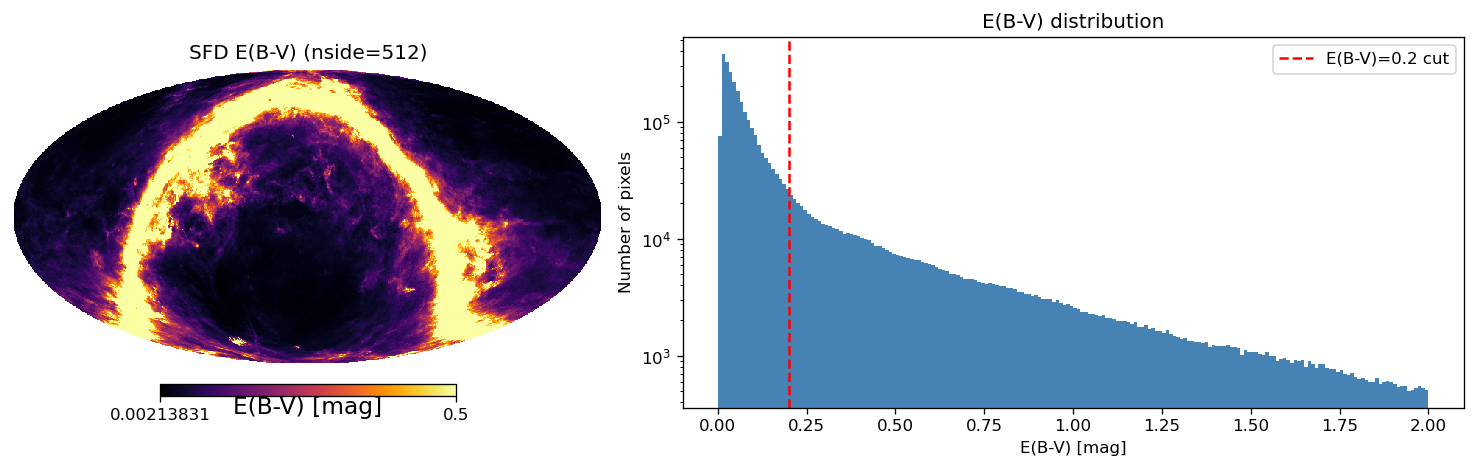

Fraction of sky with E(B-V) < 0.2: 0.7459  (30772 deg²)


In [5]:
ebv = hp.read_map(sfd_file, verbose=False)
print(f"SFD map: nside={hp.npix2nside(len(ebv))}, "
      f"min={ebv.min():.4f}, max={ebv.max():.4f}, "
      f"median={np.median(ebv):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plt.subplot(1, 2, 1)
hp.mollview(ebv, title="SFD E(B-V) (nside=512)",
            unit="E(B-V) [mag]", max=0.5, hold=True, cmap="inferno")

# Histogram with cut marked
plt.subplot(1, 2, 2)
ax = plt.gca()
ax.hist(ebv[ebv < 2.0], bins=200, color="steelblue", log=True)
ax.axvline(0.2, color="red", ls="--", label="E(B-V)=0.2 cut")
ax.set_xlabel("E(B-V) [mag]")
ax.set_ylabel("Number of pixels")
ax.set_title("E(B-V) distribution")
ax.legend()

plt.tight_layout()
plt.show()

frac_ebv = np.mean(ebv < 0.2)
print(f"Fraction of sky with E(B-V) < 0.2: {frac_ebv:.4f}  "
      f"({frac_ebv * 41253:.0f} deg²)")

## 4. Apply cuts at native resolution

In [6]:
# nside=256 masks
mask_nvisits_g  = nvisits["g"] > 1
mask_nvisits_r  = nvisits["r"] > 1
mask_nvisits_i  = nvisits["i"] > 1
mask_nvisits_z  = nvisits["z"] > 1
mask_depth_ps   = depth_ps  > 23.5
mask_depth_ext  = depth_ext > 23.5

# nside=512 mask
mask_ebv = ebv < 0.2

npix_256 = hp.nside2npix(256)
npix_512 = hp.nside2npix(512)

print("Fraction of nside=256 pixels passing each cut:")
for name, m in [("nvisits_g > 1", mask_nvisits_g),
                ("nvisits_r > 1", mask_nvisits_r),
                ("nvisits_i > 1", mask_nvisits_i),
                ("nvisits_z > 1", mask_nvisits_z),
                ("m5_ps_r > 23.5", mask_depth_ps),
                ("m5_ext_r > 23.5", mask_depth_ext)]:
    print(f"  {name:20s}: {m.mean():.4f}")

print(f"\nFraction of nside=512 pixels passing EBV < 0.2: {mask_ebv.mean():.4f}")

Fraction of nside=256 pixels passing each cut:
  nvisits_g > 1       : 0.0838
  nvisits_r > 1       : 0.0937
  nvisits_i > 1       : 0.0952
  nvisits_z > 1       : 0.0892
  m5_ps_r > 23.5      : 0.0938
  m5_ext_r > 23.5     : 0.0938

Fraction of nside=512 pixels passing EBV < 0.2: 0.7459


## 5. Upgrade nside=256 masks to nside=512

In [7]:
def upgrade(mask_256):
    """Upgrade a boolean nside=256 mask to nside=512, pessimistically.
    Each nside=256 pixel maps to 4 nside=512 sub-pixels; all four are
    masked if the parent pixel is masked (pess=True)."""
    return hp.ud_grade(mask_256.astype(float), NSIDE_OUT, pess=True) > 0.5

mask_nvisits_g_512  = upgrade(mask_nvisits_g)
mask_nvisits_r_512  = upgrade(mask_nvisits_r)
mask_nvisits_i_512  = upgrade(mask_nvisits_i)
mask_nvisits_z_512  = upgrade(mask_nvisits_z)
mask_depth_ps_512   = upgrade(mask_depth_ps)
mask_depth_ext_512  = upgrade(mask_depth_ext)

print("After upgrading to nside=512, fraction of pixels passing:")
for name, m in [("nvisits_g",    mask_nvisits_g_512),
                ("nvisits_r",    mask_nvisits_r_512),
                ("nvisits_i",    mask_nvisits_i_512),
                ("nvisits_z",    mask_nvisits_z_512),
                ("m5_ps_r",      mask_depth_ps_512),
                ("m5_ext_r",     mask_depth_ext_512),
                ("EBV",          mask_ebv)]:
    print(f"  {name:12s}: {m.mean():.4f}  ({m.sum() * OMEGA_PIX:.1f} deg²)")

After upgrading to nside=512, fraction of pixels passing:
  nvisits_g   : 0.0838  (3455.2 deg²)
  nvisits_r   : 0.0937  (3866.9 deg²)
  nvisits_i   : 0.0952  (3925.8 deg²)
  nvisits_z   : 0.0892  (3681.5 deg²)
  m5_ps_r     : 0.0938  (3871.4 deg²)
  m5_ext_r    : 0.0938  (3871.4 deg²)
  EBV         : 0.7459  (30772.2 deg²)


## 6. Combine masks and compare point-source vs extended-source versions

In [8]:
common = (mask_nvisits_g_512 & mask_nvisits_r_512 &
          mask_nvisits_i_512 & mask_nvisits_z_512 & mask_ebv)

mask_ps  = common & mask_depth_ps_512
mask_ext = common & mask_depth_ext_512

# Pixels that differ between the two versions
diff = mask_ps ^ mask_ext   # XOR: True where they disagree

print("Combined mask statistics (nside=512):")
for label, m in [("m5_ps  mask", mask_ps), ("m5_ext mask", mask_ext)]:
    area = m.sum() * OMEGA_PIX
    fsky = m.mean()
    print(f"  {label}: {m.sum():8d} unmasked pixels  |  {area:7.1f} deg²  |  f_sky={fsky:.5f}")

print(f"\n  Pixels differing between ps and ext: {diff.sum()}  "
      f"({diff.sum() * OMEGA_PIX:.2f} deg²)")

Combined mask statistics (nside=512):
  m5_ps  mask:   162004 unmasked pixels  |   2124.5 deg²  |  f_sky=0.05150
  m5_ext mask:   162004 unmasked pixels  |   2124.5 deg²  |  f_sky=0.05150

  Pixels differing between ps and ext: 0  (0.00 deg²)


/tmp/ipykernel_104830/3798296193.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


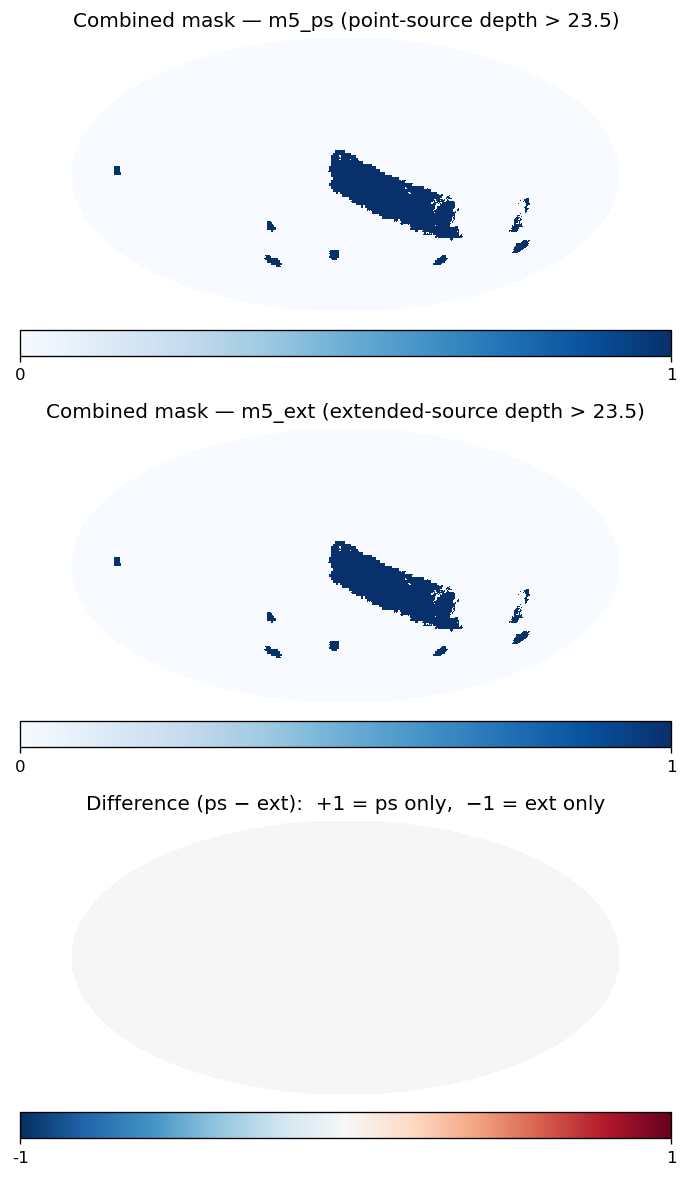

In [9]:
fig = plt.figure(figsize=(14, 12))

plt.subplot(3, 1, 1)
hp.mollview(mask_ps.astype(float),
            title="Combined mask — m5_ps (point-source depth > 23.5)",
            min=0, max=1, hold=True, cmap="Blues")

plt.subplot(3, 1, 2)
hp.mollview(mask_ext.astype(float),
            title="Combined mask — m5_ext (extended-source depth > 23.5)",
            min=0, max=1, hold=True, cmap="Blues")

plt.subplot(3, 1, 3)
# +1 = in ps only, -1 = in ext only, 0 = agree
diff_signed = mask_ps.astype(int) - mask_ext.astype(int)
hp.mollview(diff_signed.astype(float),
            title="Difference (ps − ext):  +1 = ps only,  −1 = ext only",
            min=-1, max=1, hold=True, cmap="RdBu_r")

plt.tight_layout()
plt.show()

## 7. Remove disconnected regions — keep largest connected component

We build a sparse pixel-adjacency graph over the unmasked pixels (using HEALPix neighbour lookup), find all connected components with `scipy.sparse.csgraph`, and discard everything except the largest one.

In [10]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components


def keep_largest_component(mask, nside):
    """Return a copy of `mask` with all but the largest connected component removed.

    Uses healpy neighbour lookup to build a sparse adjacency graph over unmasked
    pixels, then runs scipy connected_components.  Runs in O(n_unmasked) memory.
    """
    npix = hp.nside2npix(nside)
    unmasked_pix = np.where(mask)[0]
    n = len(unmasked_pix)

    # Map global pixel index → local index (0..n-1);  -1 for masked pixels
    pix2local = np.full(npix, -1, dtype=np.int32)
    pix2local[unmasked_pix] = np.arange(n, dtype=np.int32)

    # All 8 neighbours for every unmasked pixel at once → shape (8, n)
    all_nb = hp.get_all_neighbours(nside, unmasked_pix)

    rows_list, cols_list = [], []
    for nb_row in all_nb:                     # iterate over the 8 directions
        valid = nb_row >= 0                   # healpy uses -1 for missing neighbours
        nb_local = pix2local[np.where(valid, nb_row, 0)]   # safe indexing
        in_mask = valid & (nb_local >= 0)
        src = np.where(in_mask)[0]
        dst = nb_local[in_mask]
        rows_list.append(src)
        cols_list.append(dst)

    rows = np.concatenate(rows_list)
    cols = np.concatenate(cols_list)
    adj  = csr_matrix((np.ones(len(rows), dtype=np.float32), (rows, cols)),
                      shape=(n, n))

    n_comp, labels = connected_components(adj, directed=False)

    comp_sizes   = np.bincount(labels)
    largest_comp = np.argmax(comp_sizes)

    print(f"  {n_comp} connected components found:")
    for rank, (size, cid) in enumerate(
            sorted(zip(comp_sizes, range(n_comp)), reverse=True)):
        area = size * hp.nside2pixarea(nside, degrees=True)
        marker = " ← kept" if cid == largest_comp else ""
        print(f"    #{rank+1:2d}  {size:8d} pixels  {area:8.2f} deg²{marker}")

    clean = np.zeros(npix, dtype=bool)
    clean[unmasked_pix[labels == largest_comp]] = True
    return clean, n_comp, comp_sizes

In [11]:
print("=== m5_ps mask ===")
mask_ps_clean,  n_ps,  sizes_ps  = keep_largest_component(mask_ps,  NSIDE_OUT)

print("\n=== m5_ext mask ===")
mask_ext_clean, n_ext, sizes_ext = keep_largest_component(mask_ext, NSIDE_OUT)

print("\nAfter cleaning:")
for label, m_before, m_after in [
        ("m5_ps ", mask_ps,  mask_ps_clean),
        ("m5_ext", mask_ext, mask_ext_clean)]:
    removed = m_before.sum() - m_after.sum()
    print(f"  {label}: {m_after.sum()} pixels  "
          f"({m_after.sum() * OMEGA_PIX:.1f} deg²)  "
          f"[removed {removed} pixels = {removed * OMEGA_PIX:.2f} deg²]")

=== m5_ps mask ===
  57 connected components found:
    # 1    143352 pixels   1879.91 deg² ← kept
    # 2      3406 pixels     44.67 deg²
    # 3      3024 pixels     39.66 deg²
    # 4      2641 pixels     34.63 deg²
    # 5      2340 pixels     30.69 deg²
    # 6      2176 pixels     28.54 deg²
    # 7      1760 pixels     23.08 deg²
    # 8      1572 pixels     20.62 deg²
    # 9      1350 pixels     17.70 deg²
    #10        93 pixels      1.22 deg²
    #11        61 pixels      0.80 deg²
    #12        18 pixels      0.24 deg²
    #13        18 pixels      0.24 deg²
    #14        17 pixels      0.22 deg²
    #15        15 pixels      0.20 deg²
    #16        13 pixels      0.17 deg²
    #17        13 pixels      0.17 deg²
    #18        12 pixels      0.16 deg²
    #19        10 pixels      0.13 deg²
    #20        10 pixels      0.13 deg²
    #21         7 pixels      0.09 deg²
    #22         7 pixels      0.09 deg²
    #23         7 pixels      0.09 deg²
    #24         7 pix

/tmp/ipykernel_104830/3492061114.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


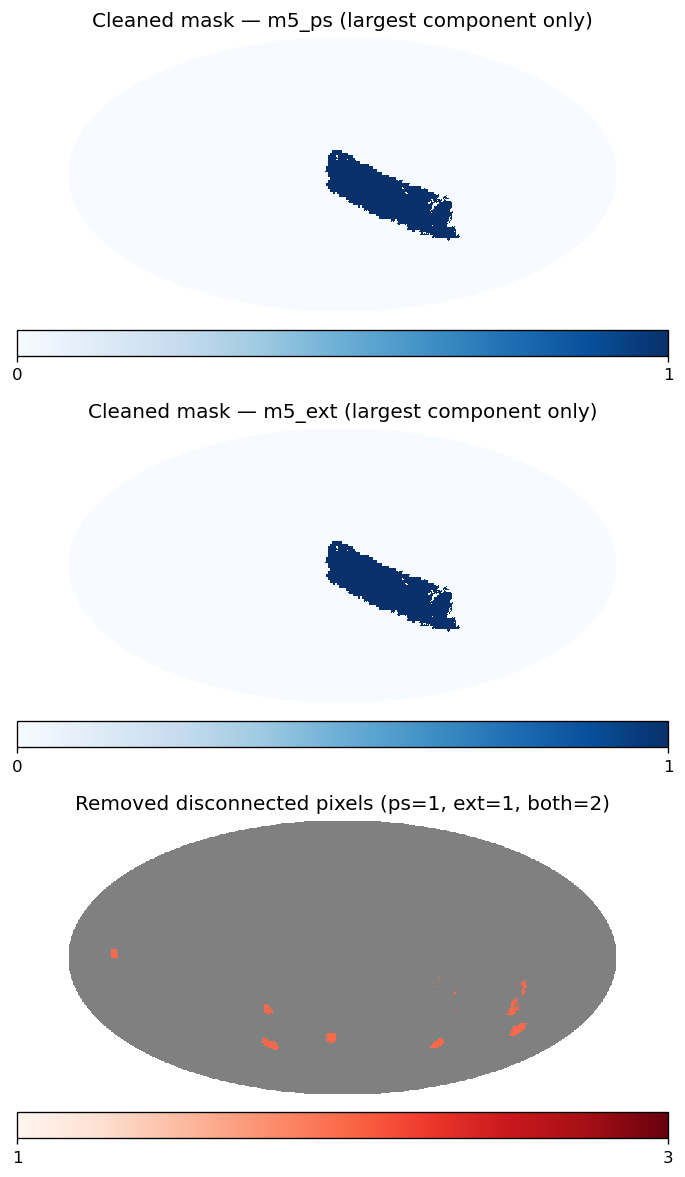

In [12]:
fig = plt.figure(figsize=(14, 12))

plt.subplot(3, 1, 1)
hp.mollview(mask_ps_clean.astype(float),
            title="Cleaned mask — m5_ps (largest component only)",
            min=0, max=1, hold=True, cmap="Blues")

plt.subplot(3, 1, 2)
hp.mollview(mask_ext_clean.astype(float),
            title="Cleaned mask — m5_ext (largest component only)",
            min=0, max=1, hold=True, cmap="Blues")

plt.subplot(3, 1, 3)
# Show removed pixels: +1 = removed from ps, -1 = removed from ext, +2 = removed from both
removed_ps  = mask_ps.astype(int)  - mask_ps_clean.astype(int)   # 1 where removed
removed_ext = mask_ext.astype(int) - mask_ext_clean.astype(int)
removed_vis = removed_ps + removed_ext   # 2=both, 1=ps only, -1=... (won't happen)
removed_map = np.where((removed_ps | removed_ext), removed_vis.astype(float), hp.UNSEEN)
hp.mollview(removed_map,
            title="Removed disconnected pixels (ps=1, ext=1, both=2)",
            hold=True, cmap="Reds")

plt.tight_layout()
plt.show()

## 8. Cardinal mock sky coverage

Read `ra` and `dec` from all 54 Cardinal tiles and build a galaxy count map at nside=512.  Only the two positional columns are loaded per file, so this is fast despite the large parquet sizes.

In [27]:
import pyarrow.parquet as pq

cardinal_root = "/global/cfs/cdirs/lsst/groups/PZ/Cardinal/parquet_files/dp2_mock_run_cardinal_gold_test"
parquet_name  = "output_deredden_lsst_obs_cond_dp2.pq"

tile_ids = [
     64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
     77,  78,  80,  81,  82,  96,  97,
    341, 342, 343, 345, 346, 347, 348, 349, 350, 351, 369,
    371, 372, 373, 374, 375,
    421, 422, 423, 425, 426, 427, 428, 429, 430, 431, 432,
    434, 435,
    440, 441, 442, 443, 444,
]

n_gal = np.zeros(hp.nside2npix(NSIDE_OUT), dtype=np.int64)
total_galaxies = 0

for tile_id in tile_ids:
    path      = f"{cardinal_root}/{tile_id}/{parquet_name}"
    table     = pq.read_table(path, columns=["ra", "dec", "mag_i_lsst_err"])
    ra        = table["ra"].to_numpy()
    dec       = table["dec"].to_numpy()
    mag_i_err = table["mag_i_lsst_err"].to_numpy()

    safe_err = np.where(mag_i_err > 0, mag_i_err, np.inf)
    snr_i    = 2.5 / (np.log(10) * safe_err)
    sel      = snr_i > 5.0

    pix = hp.ang2pix(NSIDE_OUT, ra[sel], dec[sel], lonlat=True)
    np.add.at(n_gal, pix, 1)
    total_galaxies += sel.sum()
    print(f"  tile {tile_id:4d}: {sel.sum():>12,} selected   (running total: {total_galaxies:,})")

print(f"\nTotal galaxies after SNR_i > 5 : {total_galaxies:,}")
print(f"Non-empty pixels               : {(n_gal > 0).sum():,}")


  tile   64:    3,422,627 selected   (running total: 3,422,627)
  tile   65:    4,928,564 selected   (running total: 8,351,191)
  tile   66:    5,664,327 selected   (running total: 14,015,518)
  tile   67:    5,126,224 selected   (running total: 19,141,742)
  tile   68:    4,781,892 selected   (running total: 23,923,634)
  tile   69:    4,169,236 selected   (running total: 28,092,870)
  tile   70:    3,761,294 selected   (running total: 31,854,164)
  tile   71:    1,491,273 selected   (running total: 33,345,437)
  tile   72:    6,429,411 selected   (running total: 39,774,848)
  tile   73:    4,275,865 selected   (running total: 44,050,713)
  tile   74:    4,085,465 selected   (running total: 48,136,178)
  tile   75:    1,431,379 selected   (running total: 49,567,557)
  tile   76:    1,210,264 selected   (running total: 50,777,821)
  tile   77:        5,643 selected   (running total: 50,783,464)
  tile   78:        8,277 selected   (running total: 50,791,741)
  tile   80:    1,415,461 s

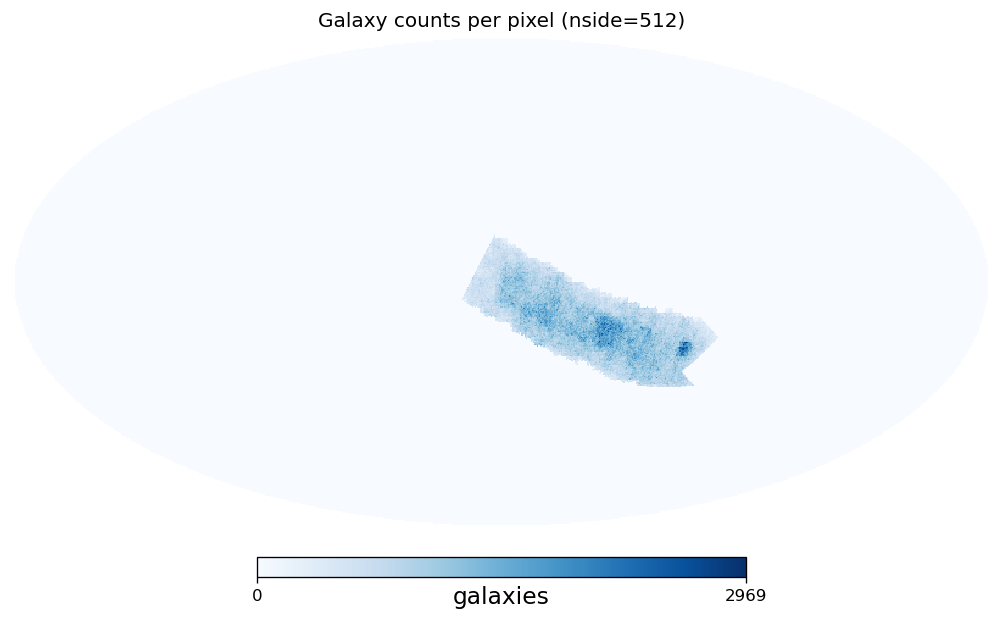

In [28]:
hp.mollview(n_gal, title="Galaxy counts per pixel (nside=512)", unit="galaxies", cmap="Blues")
plt.show()

Galaxy count statistics over non-empty pixels:
  min=1  p5=449  p10=546  p25=726  median=955  max=3303


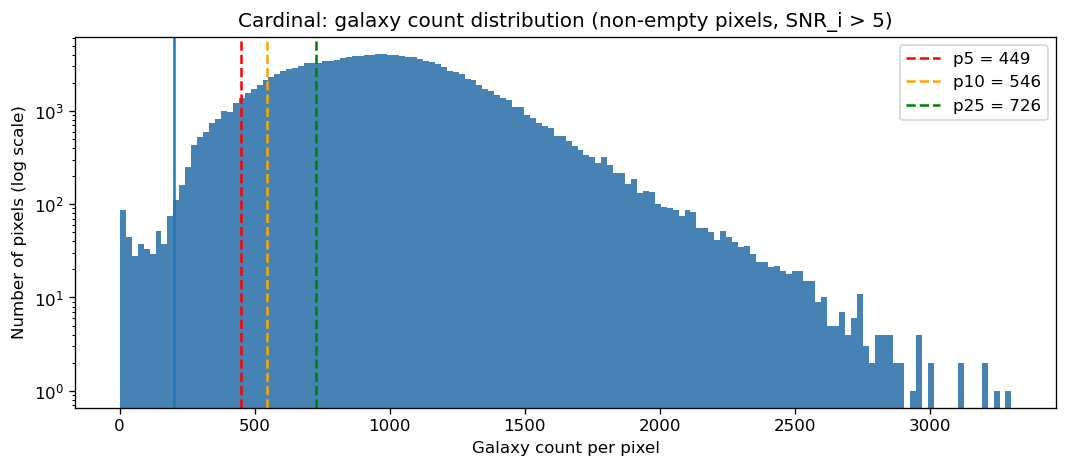

In [31]:
occupied = n_gal[n_gal > 0]
p5  = int(np.percentile(occupied, 5))
p10 = int(np.percentile(occupied, 10))
p25 = int(np.percentile(occupied, 25))
print(f"Galaxy count statistics over non-empty pixels:")
print(f"  min={occupied.min()}  p5={p5}  p10={p10}  p25={p25}  median={int(np.median(occupied))}  max={occupied.max()}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(occupied, bins=150, color="steelblue", log=True)
for val, label, color in [(p5, "p5", "red"), (p10, "p10", "orange"), (p25, "p25", "green")]:
    ax.axvline(val, color=color, ls="--", lw=1.5, label=f"{label} = {val}")
ax.set_xlabel("Galaxy count per pixel")
ax.set_ylabel("Number of pixels (log scale)")
ax.set_title("Cardinal: galaxy count distribution (non-empty pixels, SNR_i > 5)")
ax.legend()
ax.axvline(200)
plt.tight_layout()
plt.show()


In [32]:
NGAL_MIN = 200   # adjust based on the histogram above

cardinal_coverage = n_gal >= NGAL_MIN
print(f"Pixels with >= {NGAL_MIN} galaxies: {cardinal_coverage.sum():,}  "
      f"({cardinal_coverage.sum() * OMEGA_PIX:.1f} deg²  f_sky={cardinal_coverage.mean():.5f})")


Pixels with >= 200 galaxies: 152,577  (2000.9 deg²  f_sky=0.04850)


## 9. Final masks: intersect each depth version with Cardinal coverage

Two final masks are produced:
- `mask_ps_final  = mask_ps_clean  & cardinal_coverage`
- `mask_ext_final = mask_ext_clean & cardinal_coverage`

In [33]:
mask_ps_final  = mask_ps_clean  & cardinal_coverage
mask_ext_final = mask_ext_clean & cardinal_coverage

print("Mask area budget:")
for label, m_clean, m_final in [
        ("m5_ps ", mask_ps_clean,  mask_ps_final),
        ("m5_ext", mask_ext_clean, mask_ext_final)]:
    removed = m_clean.sum() - m_final.sum()
    print(f"  {label}  before coverage: {m_clean.sum():9,} pixels  {m_clean.sum() * OMEGA_PIX:8.1f} deg²")
    print(f"  {label}  final          : {m_final.sum():9,} pixels  {m_final.sum() * OMEGA_PIX:8.1f} deg²"
          f"  (f_sky={m_final.mean():.5f})")
    print(f"  {label}  lost to coverage gap: {removed:,} pixels  ({removed * OMEGA_PIX:.2f} deg²)")
    print()

Mask area budget:
  m5_ps   before coverage:   143,352 pixels    1879.9 deg²
  m5_ps   final          :   135,731 pixels    1780.0 deg²  (f_sky=0.04315)
  m5_ps   lost to coverage gap: 7,621 pixels  (99.94 deg²)

  m5_ext  before coverage:   143,352 pixels    1879.9 deg²
  m5_ext  final          :   135,731 pixels    1780.0 deg²  (f_sky=0.04315)
  m5_ext  lost to coverage gap: 7,621 pixels  (99.94 deg²)



/tmp/ipykernel_104830/2952044952.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


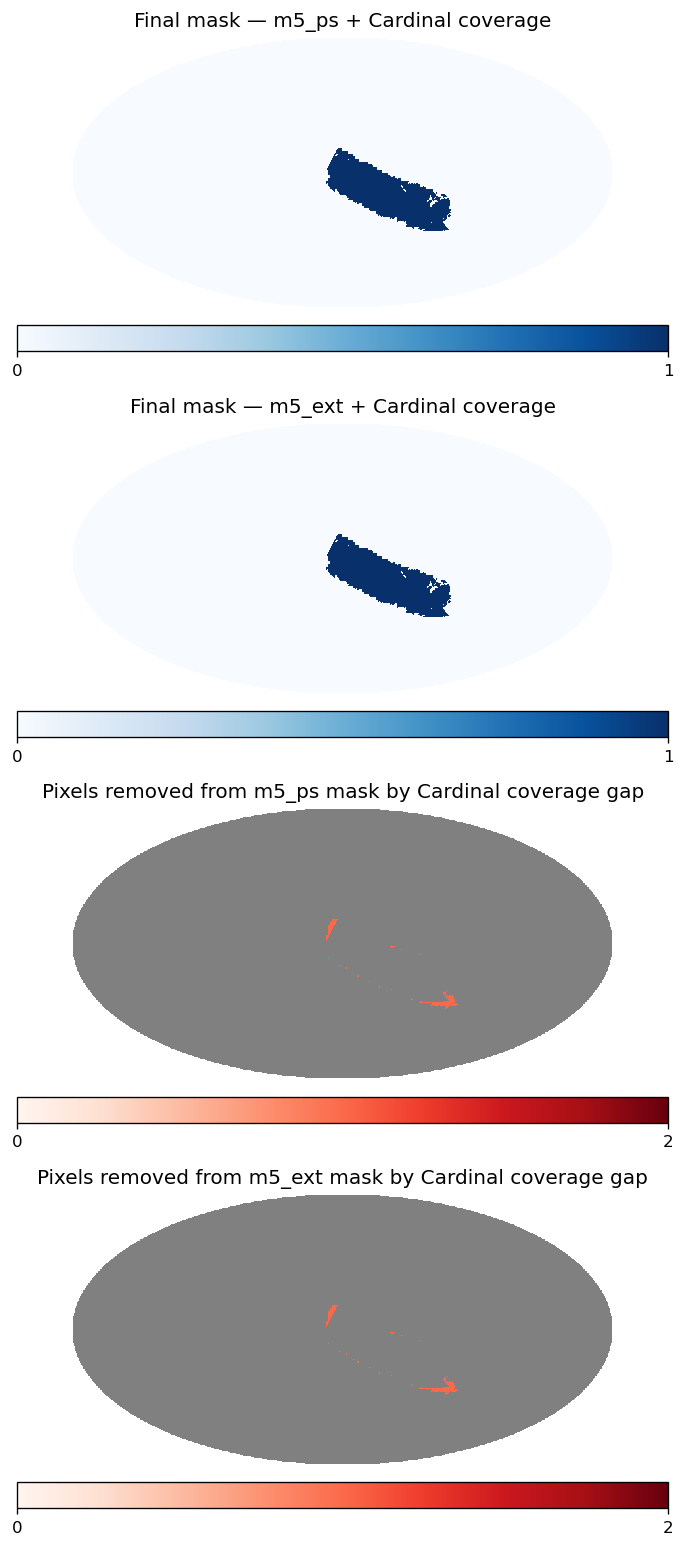

In [34]:
fig = plt.figure(figsize=(14, 16))

plt.subplot(4, 1, 1)
hp.mollview(mask_ps_final.astype(float),
            title="Final mask — m5_ps + Cardinal coverage",
            min=0, max=1, hold=True, cmap="Blues")

plt.subplot(4, 1, 2)
hp.mollview(mask_ext_final.astype(float),
            title="Final mask — m5_ext + Cardinal coverage",
            min=0, max=1, hold=True, cmap="Blues")

plt.subplot(4, 1, 3)
# Pixels removed from each mask by the coverage constraint
removed_ps  = (mask_ps_clean  & ~cardinal_coverage).astype(float)
removed_ext = (mask_ext_clean & ~cardinal_coverage).astype(float)
removed_ps_map  = np.where(removed_ps  > 0, removed_ps,  hp.UNSEEN)
removed_ext_map = np.where(removed_ext > 0, removed_ext, hp.UNSEEN)
hp.mollview(removed_ps_map,
            title="Pixels removed from m5_ps mask by Cardinal coverage gap",
            hold=True, cmap="Reds")

plt.subplot(4, 1, 4)
hp.mollview(removed_ext_map,
            title="Pixels removed from m5_ext mask by Cardinal coverage gap",
            hold=True, cmap="Reds")

plt.tight_layout()
plt.show()

## 10. Save both final masks (FITS + TXPipe HDF5)

In [35]:
import h5py


def write_txpipe_mask(mask_bool, output_hdf5, nside):
    """Write a boolean HEALPix mask to TXPipe MapsFile HDF5 format.

    Mirrors the layout produced by fits_mask_to_txpipe() in txpipe_util_old.ipynb:
      maps/
        attrs: pixelization, nside, sparse, nest
        mask/
          pixel  – int64 array of unmasked pixel indices (RING order)
          value  – float64 array of mask values (1.0 for all unmasked pixels)
          attrs: pixelization, nside, nest, area, f_sky, npix, sparse, n_unmasked
    """
    npix = hp.nside2npix(nside)
    pixel = np.where(mask_bool)[0].astype(np.int64)
    value = np.ones(len(pixel), dtype=np.float64)

    area_deg2 = len(pixel) * hp.nside2pixarea(nside, degrees=True)
    f_sky = len(pixel) / npix

    with h5py.File(output_hdf5, "w") as f:
        mg = f.create_group("maps")
        mg.attrs["pixelization"] = "healpix"
        mg.attrs["nside"]        = nside
        mg.attrs["sparse"]       = True
        mg.attrs["nest"]         = False

        mk = mg.create_group("mask")
        mk.create_dataset("pixel", data=pixel)
        mk.create_dataset("value", data=value)
        mk.attrs["pixelization"] = "healpix"
        mk.attrs["nside"]        = nside
        mk.attrs["nest"]         = False
        mk.attrs["area"]         = area_deg2
        mk.attrs["f_sky"]        = f_sky
        mk.attrs["npix"]         = npix
        mk.attrs["sparse"]       = True
        mk.attrs["n_unmasked"]   = len(pixel)

In [36]:
import os

masks_to_save = [
    ("m5_ps",  mask_ps_final,  "m5_ps_r > 23.5",  "cardinal_mask_m5ps_final_nside512"),
    ("m5_ext", mask_ext_final, "m5_ext_r > 23.5", "cardinal_mask_m5ext_final_nside512"),
]

out_dir = "/pscratch/sd/a/anicola/DP2/data/masks"
os.makedirs(out_dir, exist_ok=True)

for label, mask, depth_cut, stem in masks_to_save:
    fits_path = f"{out_dir}/{stem}.fits"
    hdf5_path = f"{out_dir}/{stem}.hdf5"

    # FITS
    hp.write_map(
        fits_path,
        mask.astype(np.int32),
        overwrite=True,
        dtype=np.int32,
        column_names=["MASK"],
        extra_header=[
            ("NSIDE",     NSIDE_OUT),
            ("ORDERING",  "RING"),
            ("DEPTH_CUT", depth_cut),
            ("NVIS_CUT",  "nvisits_griz > 1"),
            ("EBV_CUT",   "EBV < 0.2"),
            ("COV_CUT",   f"Cardinal n_gal >= {NGAL_MIN}"),
            ("NOTE",      "largest connected component only"),
        ],
    )

    # TXPipe HDF5
    write_txpipe_mask(mask, hdf5_path, NSIDE_OUT)

    # Verify
    m = hp.read_map(fits_path, verbose=False)
    print(f"{label}: {int(m.sum())} pixels  {int(m.sum()) * OMEGA_PIX:.1f} deg²  f_sky={m.mean():.5f}")
    print(f"  FITS : {fits_path}")
    print(f"  HDF5 : {hdf5_path}")
    print()

m5_ps: 135731 pixels  1780.0 deg²  f_sky=0.04315
  FITS : /pscratch/sd/a/anicola/DP2/data/masks/cardinal_mask_m5ps_final_nside512.fits
  HDF5 : /pscratch/sd/a/anicola/DP2/data/masks/cardinal_mask_m5ps_final_nside512.hdf5

m5_ext: 135731 pixels  1780.0 deg²  f_sky=0.04315
  FITS : /pscratch/sd/a/anicola/DP2/data/masks/cardinal_mask_m5ext_final_nside512.fits
  HDF5 : /pscratch/sd/a/anicola/DP2/data/masks/cardinal_mask_m5ext_final_nside512.hdf5



/tmp/ipykernel_104830/2119797743.py:37: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  m = hp.read_map(fits_path, verbose=False)


---
## 8b. Flagship Gold mock sky coverage

Read `ra`, `dec`, and `mag_i_lsst_err` from all 24 Flagship Gold pixels and build
a galaxy count map at nside=512, applying an i-band SNR > 5 cut (matching the
`snr_i_cut` set in `TXTruthLensSelector`).

In [37]:
flagship_gold_root   = "/global/cfs/cdirs/lsst/groups/PZ/Flagship/dp2_mock_run_flagship_gold_test"
parquet_name_fg      = "output_deredden_lsst_obs_cond_dp2.pq"
flagship_gold_pixels = list(range(24))

n_gal_fg      = np.zeros(hp.nside2npix(NSIDE_OUT), dtype=np.int64)
total_gals_fg = 0

for pix_id in flagship_gold_pixels:
    path      = f"{flagship_gold_root}/{pix_id}/{parquet_name_fg}"
    table     = pq.read_table(path, columns=["ra", "dec", "mag_i_lsst_err"])
    ra        = table["ra"].to_numpy()
    dec       = table["dec"].to_numpy()
    mag_i_err = table["mag_i_lsst_err"].to_numpy()

    safe_err = np.where(mag_i_err > 0, mag_i_err, np.inf)
    snr_i    = 2.5 / (np.log(10) * safe_err)
    sel      = snr_i > 5.0

    pix_hp = hp.ang2pix(NSIDE_OUT, ra[sel], dec[sel], lonlat=True)
    np.add.at(n_gal_fg, pix_hp, 1)
    total_gals_fg += sel.sum()
    print(f"  pixel {pix_id:2d}: {sel.sum():>12,} selected   (running total: {total_gals_fg:,})")

print(f"\nTotal galaxies after SNR_i > 5: {total_gals_fg:,}")
print(f"Non-empty pixels               : {(n_gal_fg > 0).sum():,}")


  pixel  0:   13,078,047 selected   (running total: 13,078,047)
  pixel  1:    7,391,748 selected   (running total: 20,469,795)
  pixel  2:    5,405,829 selected   (running total: 25,875,624)
  pixel  3:    5,279,134 selected   (running total: 31,154,758)
  pixel  4:    5,784,886 selected   (running total: 36,939,644)
  pixel  5:    5,358,786 selected   (running total: 42,298,430)
  pixel  6:    4,309,077 selected   (running total: 46,607,507)
  pixel  7:    4,474,612 selected   (running total: 51,082,119)
  pixel  8:   12,762,489 selected   (running total: 63,844,608)
  pixel  9:   10,438,842 selected   (running total: 74,283,450)
  pixel 10:   12,882,653 selected   (running total: 87,166,103)
  pixel 11:    9,683,954 selected   (running total: 96,850,057)
  pixel 12:   10,275,920 selected   (running total: 107,125,977)
  pixel 13:    9,058,357 selected   (running total: 116,184,334)
  pixel 14:    8,306,852 selected   (running total: 124,491,186)
  pixel 15:    6,346,192 selected   (

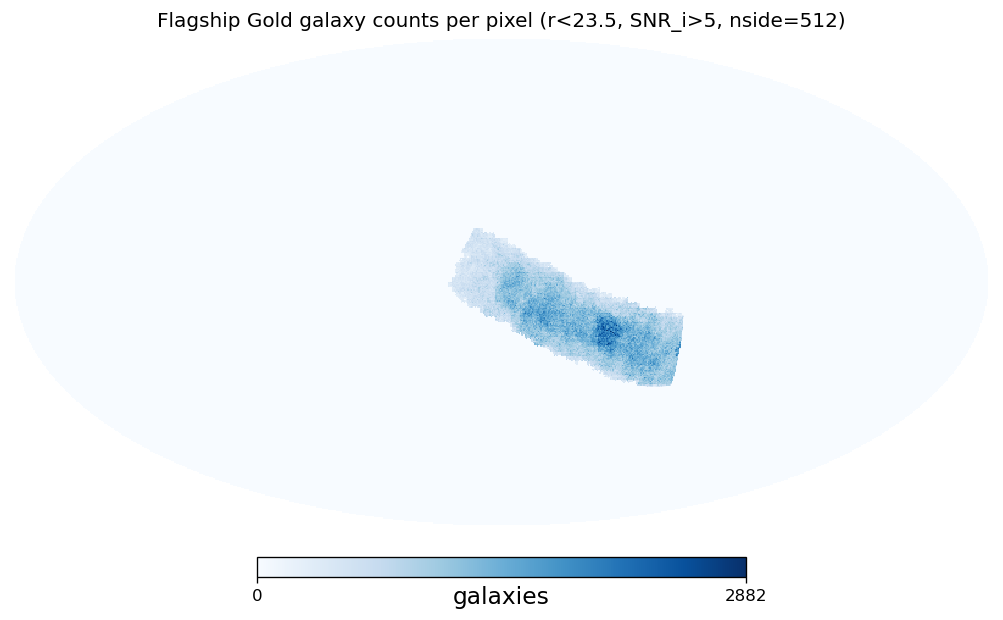

In [38]:
hp.mollview(n_gal_fg,
            title="Flagship Gold galaxy counts per pixel (r<23.5, SNR_i>5, nside=512)",
            unit="galaxies", cmap="Blues")
plt.show()


Count statistics over non-empty pixels:
  min=1  p5=435  p25=718  median=1028  max=3475


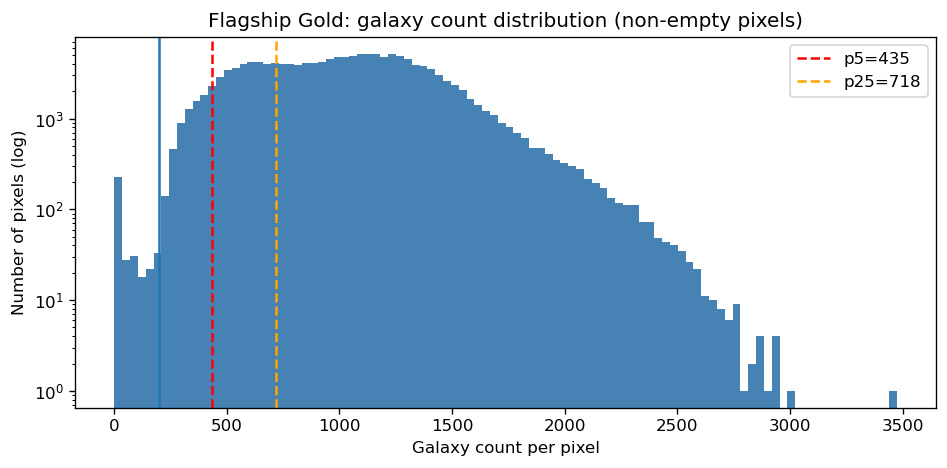

In [39]:
# Inspect the distribution to pick an appropriate nmin threshold
occupied = n_gal_fg[n_gal_fg > 0]
p5  = int(np.percentile(occupied, 5))
p25 = int(np.percentile(occupied, 25))
print(f"Count statistics over non-empty pixels:")
print(f"  min={occupied.min()}  p5={p5}  p25={p25}  median={int(np.median(occupied))}  max={occupied.max()}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(occupied, bins=100, color="steelblue", log=True)
for val, label, color in [(p5, "p5", "red"), (p25, "p25", "orange")]:
    ax.axvline(val, color=color, ls="--", label=f"{label}={val}")
ax.set_xlabel("Galaxy count per pixel")
ax.set_ylabel("Number of pixels (log)")
ax.set_title("Flagship Gold: galaxy count distribution (non-empty pixels)")
ax.legend()
ax.axvline(200)
plt.tight_layout()
plt.show()


In [40]:
NGAL_MIN_FG = 250   # adjust after inspecting the histogram above

flagship_coverage = n_gal_fg >= NGAL_MIN_FG
print(f"Flagship Gold pixels with >= {NGAL_MIN_FG} galaxies: {flagship_coverage.sum():,}  "
      f"({flagship_coverage.sum() * OMEGA_PIX:.1f} deg²)")


Flagship Gold pixels with >= 250 galaxies: 151,114  (1981.7 deg²)


## 9b. Final masks: intersect each depth version with Flagship Gold coverage

Reuses `mask_ps_clean` and `mask_ext_clean` from the Cardinal processing above.

In [41]:
mask_ps_fg_final  = mask_ps_clean  & flagship_coverage
mask_ext_fg_final = mask_ext_clean & flagship_coverage

print("Flagship Gold mask area budget:")
for label, m_clean, m_final in [
        ("m5_ps ", mask_ps_clean,  mask_ps_fg_final),
        ("m5_ext", mask_ext_clean, mask_ext_fg_final)]:
    removed = m_clean.sum() - m_final.sum()
    print(f"  {label}  survey mask only : {m_clean.sum():9,} pixels  {m_clean.sum() * OMEGA_PIX:8.1f} deg²")
    print(f"  {label}  final            : {m_final.sum():9,} pixels  {m_final.sum() * OMEGA_PIX:8.1f} deg²"
          f"  (f_sky={m_final.mean():.5f})")
    print(f"  {label}  lost to coverage : {removed:,} pixels  ({removed * OMEGA_PIX:.2f} deg²)")
    print()


Flagship Gold mask area budget:
  m5_ps   survey mask only :   143,352 pixels    1879.9 deg²
  m5_ps   final            :   130,755 pixels    1714.7 deg²  (f_sky=0.04157)
  m5_ps   lost to coverage : 12,597 pixels  (165.20 deg²)

  m5_ext  survey mask only :   143,352 pixels    1879.9 deg²
  m5_ext  final            :   130,755 pixels    1714.7 deg²  (f_sky=0.04157)
  m5_ext  lost to coverage : 12,597 pixels  (165.20 deg²)



/tmp/ipykernel_104830/1891916820.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


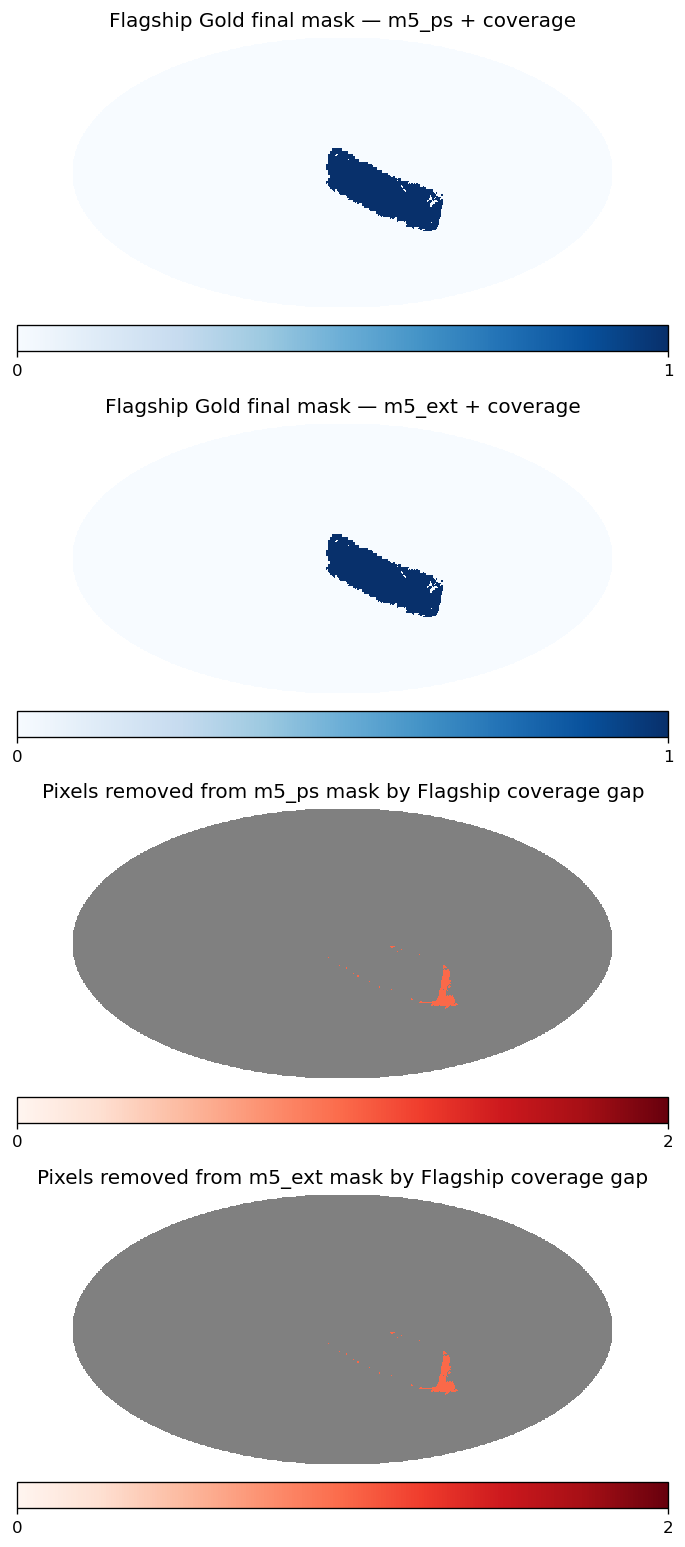

In [42]:
fig = plt.figure(figsize=(14, 16))

plt.subplot(4, 1, 1)
hp.mollview(mask_ps_fg_final.astype(float),
            title="Flagship Gold final mask — m5_ps + coverage",
            min=0, max=1, hold=True, cmap="Blues")

plt.subplot(4, 1, 2)
hp.mollview(mask_ext_fg_final.astype(float),
            title="Flagship Gold final mask — m5_ext + coverage",
            min=0, max=1, hold=True, cmap="Blues")

plt.subplot(4, 1, 3)
removed_ps_fg  = (mask_ps_clean  & ~flagship_coverage).astype(float)
removed_ext_fg = (mask_ext_clean & ~flagship_coverage).astype(float)
hp.mollview(np.where(removed_ps_fg  > 0, removed_ps_fg,  hp.UNSEEN),
            title="Pixels removed from m5_ps mask by Flagship coverage gap",
            hold=True, cmap="Reds")

plt.subplot(4, 1, 4)
hp.mollview(np.where(removed_ext_fg > 0, removed_ext_fg, hp.UNSEEN),
            title="Pixels removed from m5_ext mask by Flagship coverage gap",
            hold=True, cmap="Reds")

plt.tight_layout()
plt.show()


## 10b. Save Flagship Gold final masks (FITS + TXPipe HDF5)

In [43]:
fg_masks_to_save = [
    ("m5_ps",  mask_ps_fg_final,  "m5_ps_r > 23.5",  "flagship_gold_snri5_mask_m5ps_final_nside512"),
    ("m5_ext", mask_ext_fg_final, "m5_ext_r > 23.5", "flagship_gold_snri5_mask_m5ext_final_nside512"),
]

for label, mask, depth_cut, stem in fg_masks_to_save:
    fits_path = f"{out_dir}/{stem}.fits"
    hdf5_path = f"{out_dir}/{stem}.hdf5"

    hp.write_map(
        fits_path,
        mask.astype(np.int32),
        overwrite=True,
        dtype=np.int32,
        column_names=["MASK"],
        extra_header=[
            ("NSIDE",     NSIDE_OUT),
            ("ORDERING",  "RING"),
            ("DEPTH_CUT", depth_cut),
            ("NVIS_CUT",  "nvisits_griz > 1"),
            ("EBV_CUT",   "EBV < 0.2"),
            ("COV_CUT",   f"Flagship Gold n_gal >= {NGAL_MIN_FG} (SNR_i > 5)"),
            ("NOTE",      "largest connected component only"),
        ],
    )

    write_txpipe_mask(mask, hdf5_path, NSIDE_OUT)

    m = hp.read_map(fits_path, verbose=False)
    print(f"{label}: {int(m.sum())} pixels  {int(m.sum()) * OMEGA_PIX:.1f} deg²  f_sky={m.mean():.5f}")
    print(f"  FITS : {fits_path}")
    print(f"  HDF5 : {hdf5_path}")
    print()


m5_ps: 130755 pixels  1714.7 deg²  f_sky=0.04157
  FITS : /pscratch/sd/a/anicola/DP2/data/masks/flagship_gold_snri5_mask_m5ps_final_nside512.fits
  HDF5 : /pscratch/sd/a/anicola/DP2/data/masks/flagship_gold_snri5_mask_m5ps_final_nside512.hdf5

m5_ext: 130755 pixels  1714.7 deg²  f_sky=0.04157
  FITS : /pscratch/sd/a/anicola/DP2/data/masks/flagship_gold_snri5_mask_m5ext_final_nside512.fits
  HDF5 : /pscratch/sd/a/anicola/DP2/data/masks/flagship_gold_snri5_mask_m5ext_final_nside512.hdf5



/tmp/ipykernel_104830/3351701970.py:29: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  m = hp.read_map(fits_path, verbose=False)
